# 01C — Exploration Dataset 3 : FEMTO PRONOSTIA (IEEE PHM 2012)

**Objectif** : Explorer le dataset de roulements PRONOSTIA — séries temporelles d'accélération vibratoire jusqu'à la défaillance — et visualiser les propriétés clés pour appuyer le **Gap 1** (validation sur données industrielles réelles).

- **Dataset** : `data/raw/Pronostia dataset/binaries/{0..5}.npy`
- **Label** : `pre_failure` — 0 = normal, 1 = pré-défaillance (derniers 10% de la durée de vie)
- **Scénario CL** : Domain-Incremental par condition opératoire (RPM + charge)
  - Task 1 = Condition 1 : 1 800 rpm, 4 000 N (Bearing1_1 + Bearing1_2)
  - Task 2 = Condition 2 : 1 650 rpm, 4 200 N (Bearing2_1 + Bearing2_2)
  - Task 3 = Condition 3 : 1 500 rpm, 5 000 N (Bearing3_1 + Bearing3_2)

**Citation** : Nectoux et al., *PRONOSTIA: An Experimental Platform for Bearings Accelerated Life Test*, IEEE PHM 2012.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "..")
from src.data.pronostia_dataset import (
    CHANNEL_NAMES,
    COL_ACC_HORIZ,
    COL_ACC_VERT,
    CONDITION_BEARING_MAP,
    FAILURE_RATIO,
    FEATURE_NAMES,
    WINDOW_SIZE,
    load_bearing_features,
)
from src.evaluation.eda_plots import (
    COLORS_LABEL,
    FIGURE_DPI,
    FIGURE_FONT_SIZE,
    plot_boxplots_by_group_and_label,
    plot_boxplots_by_label,
    plot_kde_by_group_and_label,
    plot_kde_by_label,
    plot_label_distribution,
    plot_sorted_scatter_by_label,
)

NPY_DIR = pathlib.Path("../data/raw/Pronostia dataset/binaries")
FIGURES_DIR = pathlib.Path("figures/eda/pronostia")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

BEARING_NAMES = [
    "Bearing1_1", "Bearing1_2",
    "Bearing2_1", "Bearing2_2",
    "Bearing3_1", "Bearing3_2",
]
CONDITION_META = {
    1: {"rpm": 1800, "load_N": 4000, "label": "Cond 1\n1800rpm / 4000N"},
    2: {"rpm": 1650, "load_N": 4200, "label": "Cond 2\n1650rpm / 4200N"},
    3: {"rpm": 1500, "load_N": 5000, "label": "Cond 3\n1500rpm / 5000N"},
}
ACC_FEATURES = [f for f in FEATURE_NAMES if f != "temporal_position"]

print("Setup OK")
print(f"Features extraites ({len(FEATURE_NAMES)}) : {FEATURE_NAMES}")

Setup OK
Features extraites (13) : ['mean_acc_horiz', 'std_acc_horiz', 'rms_acc_horiz', 'kurtosis_acc_horiz', 'peak_acc_horiz', 'crest_factor_acc_horiz', 'mean_acc_vert', 'std_acc_vert', 'rms_acc_vert', 'kurtosis_acc_vert', 'peak_acc_vert', 'crest_factor_acc_vert', 'temporal_position']


In [2]:
# Chargement des 6 fichiers .npy bruts + extraction des features par roulement
raw_signals: dict[str, np.ndarray] = {}
bearing_features: dict[str, tuple[np.ndarray, np.ndarray]] = {}

for idx, name in enumerate(BEARING_NAMES):
    path = NPY_DIR / f"{idx}.npy"
    raw = np.load(path)  # [N_samples, 6]
    raw_signals[name] = raw
    feats, labels = load_bearing_features(path)
    bearing_features[name] = (feats, labels)
    n_windows = len(labels)
    n_fail = int(labels.sum())
    print(f"{name} : {len(raw):>7} samples bruts → {n_windows:>4} fenêtres ({n_fail} pré-failure)")

# DataFrame global de features
dfs = []
for cond_id, bear_idxs in CONDITION_BEARING_MAP.items():
    for bear_idx in bear_idxs:
        name = BEARING_NAMES[bear_idx]
        feats, labels = bearing_features[name]
        df_b = pd.DataFrame(feats, columns=FEATURE_NAMES)
        df_b["label"] = labels.astype(int)
        df_b["bearing"] = name
        df_b["condition"] = cond_id
        df_b["epoch_idx"] = np.arange(len(labels))
        dfs.append(df_b)

df_all = pd.concat(dfs, ignore_index=True)
df_all["condition_label"] = df_all["condition"].map(lambda c: f"Condition {c}")
print(f"\nDataFrame global : {df_all.shape}")
print(f"Taux pré-failure global : {df_all['label'].mean():.3f}")

Bearing1_1 : 7175680 samples bruts → 2803 fenêtres (281 pré-failure)
Bearing1_2 : 2229760 samples bruts →  871 fenêtres (88 pré-failure)
Bearing2_1 : 2332160 samples bruts →  911 fenêtres (92 pré-failure)
Bearing2_2 : 2040320 samples bruts →  797 fenêtres (80 pré-failure)
Bearing3_1 : 1318400 samples bruts →  515 fenêtres (52 pré-failure)
Bearing3_2 : 4190720 samples bruts → 1637 fenêtres (164 pré-failure)

DataFrame global : (7534, 18)
Taux pré-failure global : 0.100


---
## Section 1 — Vue d'ensemble du dataset

In [3]:
# Tableau récapitulatif
summary_rows = []
for cond_id, bear_idxs in CONDITION_BEARING_MAP.items():
    meta = CONDITION_META[cond_id]
    for bear_idx in bear_idxs:
        name = BEARING_NAMES[bear_idx]
        feats, labels = bearing_features[name]
        raw = raw_signals[name]
        summary_rows.append({
            "Roulement": name,
            "Condition": cond_id,
            "RPM": meta["rpm"],
            "Charge (N)": meta["load_N"],
            "Samples bruts": len(raw),
            "N epochs": len(labels),
            "N pré-failure": int(labels.sum()),
            "Taux failure": f"{labels.mean():.1%}",
        })

df_summary = pd.DataFrame(summary_rows)
print("Résumé du Learning Set PRONOSTIA :")
display(df_summary.set_index("Roulement"))

Résumé du Learning Set PRONOSTIA :


,Condition,RPM,Charge (N),Samples bruts,N epochs,N pré-failure,Taux failure
Roulement,,,,,,,
Bearing1_1,1,1800,4000,7175680,2803,281,10.0%
Bearing1_2,1,1800,4000,2229760,871,88,10.1%
Bearing2_1,2,1650,4200,2332160,911,92,10.1%
Bearing2_2,2,1650,4200,2040320,797,80,10.0%
Bearing3_1,3,1500,5000,1318400,515,52,10.1%
Bearing3_2,3,1500,5000,4190720,1637,164,10.0%


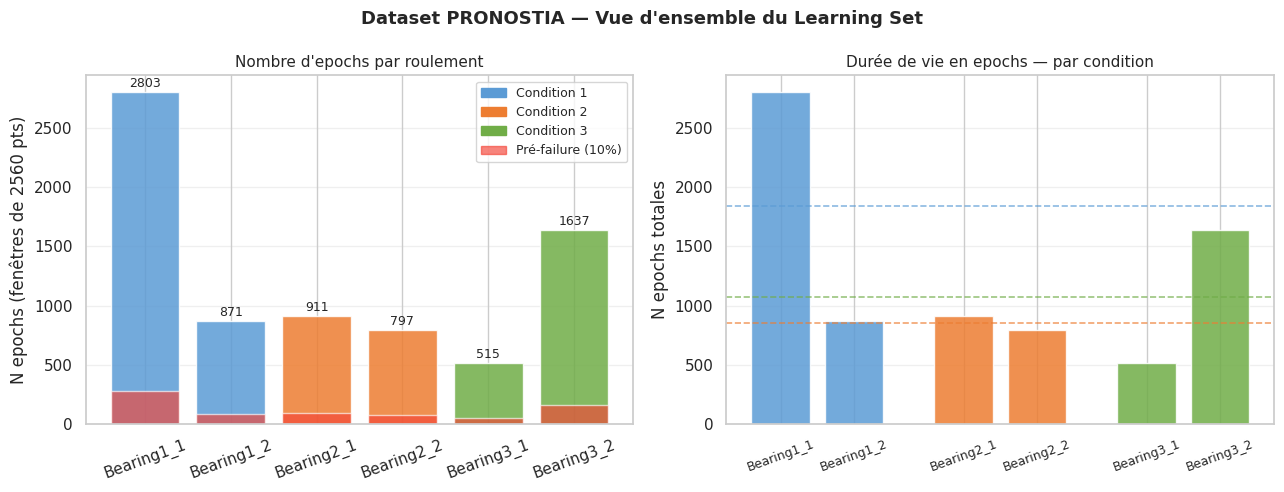

✓ Sauvegardé : figures/eda/pronostia/dataset_overview.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Bar chart : nombre d'epochs par roulement, coloré par condition
cond_colors = {1: "#5B9BD5", 2: "#ED7D31", 3: "#70AD47"}
n_epochs_list = [len(bearing_features[n][1]) for n in BEARING_NAMES]
n_fail_list   = [int(bearing_features[n][1].sum()) for n in BEARING_NAMES]
cond_list     = [1, 1, 2, 2, 3, 3]

bars = axes[0].bar(
    BEARING_NAMES, n_epochs_list,
    color=[cond_colors[c] for c in cond_list], alpha=0.85, edgecolor="white"
)
axes[0].bar(
    BEARING_NAMES, n_fail_list,
    color="#F44336", alpha=0.65, edgecolor="white", label="Pré-failure"
)
for bar, n in zip(bars, n_epochs_list):
    axes[0].text(bar.get_x() + bar.get_width() / 2, n + 15,
                 str(n), ha="center", va="bottom", fontsize=9)
axes[0].set_title("Nombre d'epochs par roulement", fontsize=FIGURE_FONT_SIZE)
axes[0].set_ylabel("N epochs (fenêtres de 2560 pts)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, axis="y", alpha=0.3)
# Légende conditions
from matplotlib.patches import Patch
legend_handles = [Patch(color=cond_colors[c], label=f"Condition {c}") for c in [1, 2, 3]]
legend_handles.append(Patch(color="#F44336", alpha=0.65, label="Pré-failure (10%)"))
axes[0].legend(handles=legend_handles, fontsize=9)

# -- Bar chart : durée de vie relative (normalisation sur le max par condition)
cond_epochs = {c: [] for c in [1, 2, 3]}
for i, name in enumerate(BEARING_NAMES):
    cond_epochs[cond_list[i]].append((name, n_epochs_list[i]))

x_pos, x_labels, bar_colors = [], [], []
x = 0
for c in [1, 2, 3]:
    for name, n in cond_epochs[c]:
        x_pos.append(x)
        x_labels.append(name)
        bar_colors.append(cond_colors[c])
        x += 1
    x += 0.5  # gap entre conditions

axes[1].bar(x_pos, [n for c in [1,2,3] for _, n in cond_epochs[c]],
            color=bar_colors, alpha=0.85, edgecolor="white")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=20, fontsize=9)
axes[1].set_title("Durée de vie en epochs — par condition", fontsize=FIGURE_FONT_SIZE)
axes[1].set_ylabel("N epochs totales")
axes[1].grid(True, axis="y", alpha=0.3)
for c, color in cond_colors.items():
    axes[1].axhline(y=np.mean([n for _, n in cond_epochs[c]]),
                    color=color, linestyle="--", linewidth=1.2, alpha=0.7)

fig.suptitle("Dataset PRONOSTIA — Vue d'ensemble du Learning Set",
             fontsize=FIGURE_FONT_SIZE + 2, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "dataset_overview.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'dataset_overview.png'}")

---
## Section 2 — Signal brut : visualisation temporelle d'une epoch

Chaque fichier `.npy` contient l'enregistrement continu d'un roulement à 25,6 kHz.
Une epoch = 2560 points = 0,1 seconde. On compare ici 3 epochs représentatives :
début de vie (normale), milieu de vie, et fin de vie (pré-défaillance).

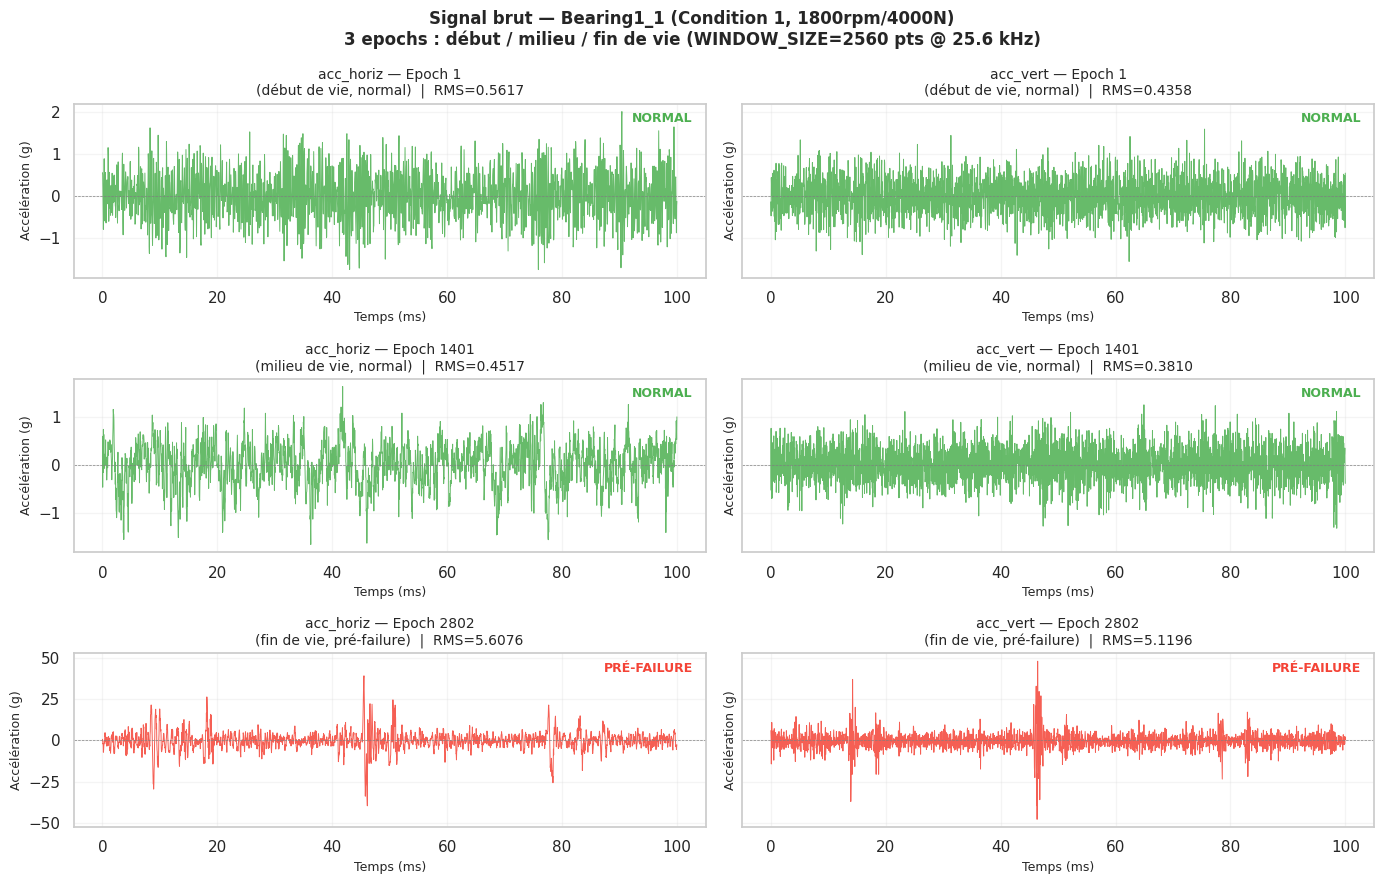

✓ Sauvegardé : figures/eda/pronostia/raw_signal_epochs_Bearing1_1.png


In [5]:
def plot_raw_epochs(raw: np.ndarray, bearing_name: str, save_path=None):
    """Affiche 3 epochs du signal brut (début / milieu / fin de vie)."""
    n_total = len(raw)
    n_epochs = n_total // WINDOW_SIZE
    failure_start = int(n_epochs * (1 - FAILURE_RATIO))

    epoch_indices = {
        "Epoch 1\n(début de vie, normal)": 0,
        f"Epoch {n_epochs // 2}\n(milieu de vie, normal)": n_epochs // 2,
        f"Epoch {n_epochs - 1}\n(fin de vie, pré-failure)": n_epochs - 1,
    }

    t_ms = np.linspace(0, 100, WINDOW_SIZE)  # 0.1 s = 100 ms

    fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharey="row")

    for row_idx, (epoch_label, ep_idx) in enumerate(epoch_indices.items()):
        start = ep_idx * WINDOW_SIZE
        segment = raw[start : start + WINDOW_SIZE]  # [2560, 6]
        is_failure = ep_idx >= failure_start
        color = COLORS_LABEL[1] if is_failure else COLORS_LABEL[0]
        alpha = 0.85

        for col_idx, (ch_name, col_idx_npy) in enumerate(
            zip(CHANNEL_NAMES, [COL_ACC_HORIZ, COL_ACC_VERT])
        ):
            ax = axes[row_idx][col_idx]
            signal = segment[:, col_idx_npy]
            rms_val = float(np.sqrt(np.mean(signal ** 2)))
            ax.plot(t_ms, signal, color=color, lw=0.7, alpha=alpha)
            ax.axhline(0, color="gray", lw=0.5, linestyle="--")
            ax.set_title(
                f"{ch_name} — {epoch_label}  |  RMS={rms_val:.4f}",
                fontsize=FIGURE_FONT_SIZE - 1,
            )
            ax.set_xlabel("Temps (ms)", fontsize=FIGURE_FONT_SIZE - 2)
            ax.set_ylabel("Accélération (g)", fontsize=FIGURE_FONT_SIZE - 2)
            ax.grid(True, alpha=0.2)
            # Annotation label
            label_text = "PRÉ-FAILURE" if is_failure else "NORMAL"
            ax.text(0.98, 0.95, label_text, transform=ax.transAxes,
                    ha="right", va="top", fontsize=9, color=color, fontweight="bold")

    fig.suptitle(
        f"Signal brut — {bearing_name} (Condition 1, 1800rpm/4000N)\n"
        f"3 epochs : début / milieu / fin de vie (WINDOW_SIZE={WINDOW_SIZE} pts @ 25.6 kHz)",
        fontsize=FIGURE_FONT_SIZE + 1, fontweight="bold"
    )
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    return fig


fig = plot_raw_epochs(
    raw_signals["Bearing1_1"], "Bearing1_1",
    save_path=FIGURES_DIR / "raw_signal_epochs_Bearing1_1.png"
)
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'raw_signal_epochs_Bearing1_1.png'}")

---
## Section 3 — Trajectoire de dégradation

Le RMS et le crest_factor évoluent typiquement de façon stable en début de vie puis s'emballent en phase terminale.
Cette section visualise la courbe de dégradation pour les 6 roulements — le signal clé pour le scénario CL.

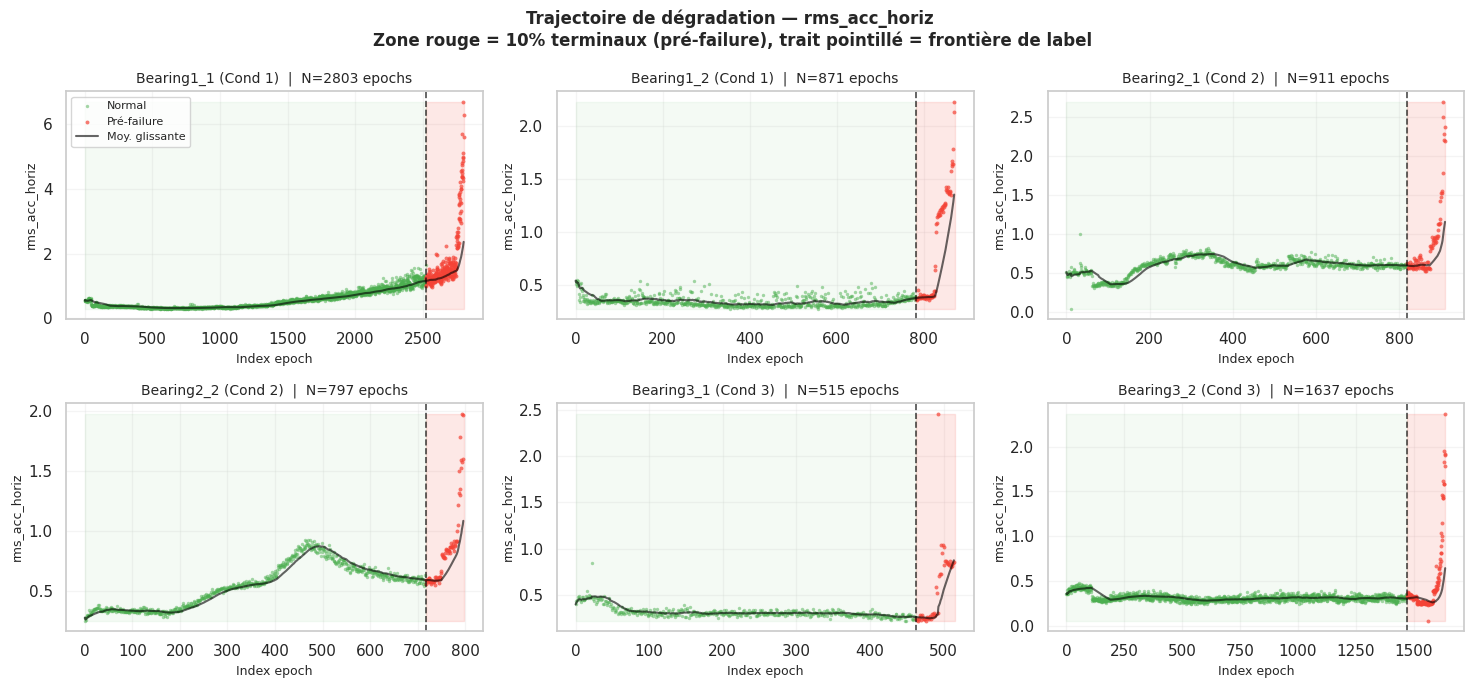

✓ Sauvegardé : figures/eda/pronostia/degradation_rms_horiz.png


In [6]:
def plot_degradation_trajectory(
    feature_name: str, title_suffix: str = "", save_path=None
):
    """Trace la trajectoire de dégradation d'une feature pour les 6 roulements."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=False)

    for idx, (ax, bear_name) in enumerate(zip(axes.flat, BEARING_NAMES)):
        feats, labels = bearing_features[bear_name]
        feat_idx = FEATURE_NAMES.index(feature_name)
        values = feats[:, feat_idx]
        n_windows = len(values)
        failure_start = int(n_windows * (1 - FAILURE_RATIO))
        cond_id = cond_list[idx]

        # Zone normale (vert)
        ax.fill_betweenx(
            [values.min(), values.max()],
            0, failure_start,
            color=COLORS_LABEL[0], alpha=0.06
        )
        # Zone pré-failure (rouge)
        ax.fill_betweenx(
            [values.min(), values.max()],
            failure_start, n_windows,
            color=COLORS_LABEL[1], alpha=0.12
        )

        ax.scatter(
            np.arange(failure_start), values[:failure_start],
            c=COLORS_LABEL[0], s=6, alpha=0.5, linewidths=0, label="Normal"
        )
        ax.scatter(
            np.arange(failure_start, n_windows), values[failure_start:],
            c=COLORS_LABEL[1], s=8, alpha=0.7, linewidths=0, label="Pré-failure"
        )

        # Ligne de séparation
        ax.axvline(failure_start, color="black", linestyle="--", lw=1.2, alpha=0.7)

        # Moyenne glissante
        roll = pd.Series(values).rolling(max(1, n_windows // 20), min_periods=1).mean()
        ax.plot(roll, color="black", lw=1.5, alpha=0.6, label="Moy. glissante")

        ax.set_title(
            f"{bear_name} (Cond {cond_id})  |  N={n_windows} epochs",
            fontsize=FIGURE_FONT_SIZE - 1
        )
        ax.set_xlabel("Index epoch", fontsize=FIGURE_FONT_SIZE - 2)
        ax.set_ylabel(feature_name, fontsize=FIGURE_FONT_SIZE - 2)
        ax.grid(True, alpha=0.2)
        if idx == 0:
            ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(
        f"Trajectoire de dégradation — {feature_name} {title_suffix}\n"
        f"Zone rouge = {FAILURE_RATIO:.0%} terminaux (pré-failure), "
        f"trait pointillé = frontière de label",
        fontsize=FIGURE_FONT_SIZE + 1, fontweight="bold"
    )
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    return fig


fig = plot_degradation_trajectory(
    "rms_acc_horiz",
    save_path=FIGURES_DIR / "degradation_rms_horiz.png"
)
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'degradation_rms_horiz.png'}")

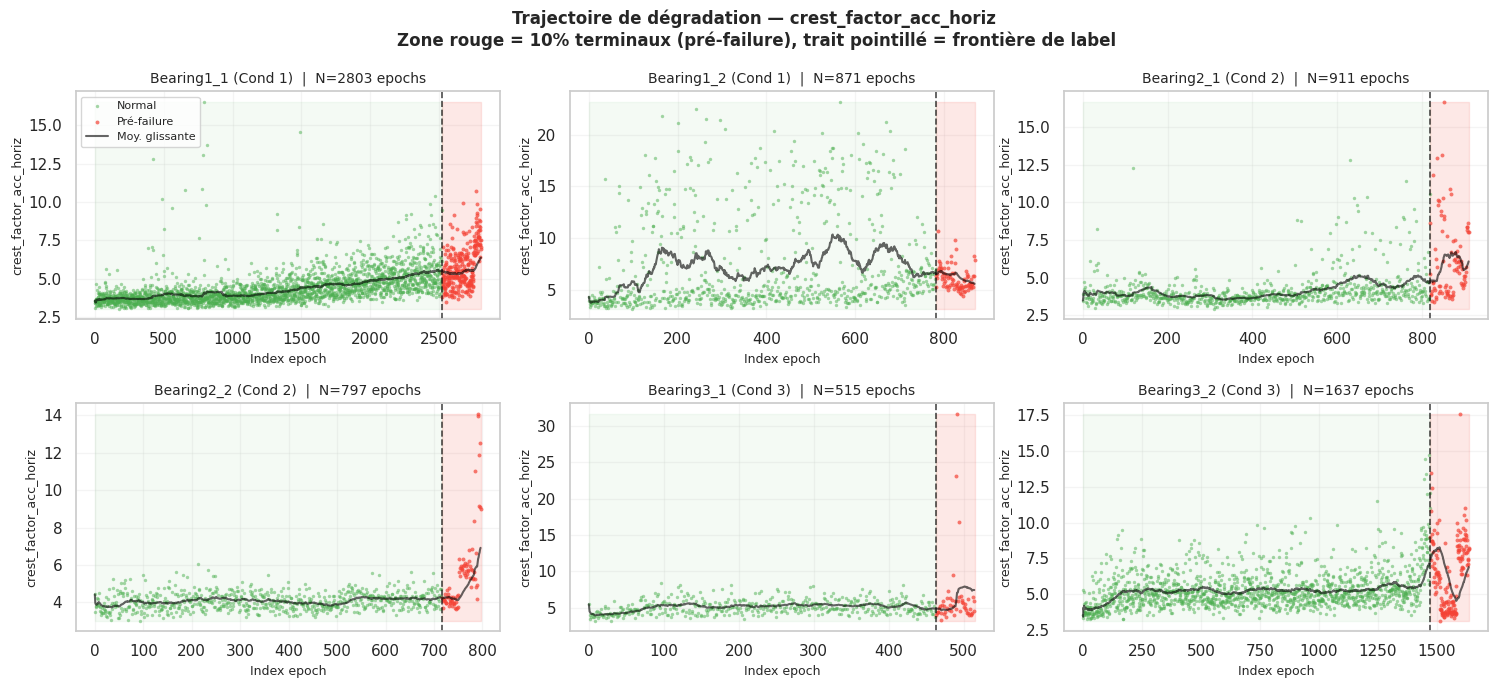

✓ Sauvegardé : figures/eda/pronostia/degradation_crest_horiz.png


In [7]:
fig = plot_degradation_trajectory(
    "crest_factor_acc_horiz",
    save_path=FIGURES_DIR / "degradation_crest_horiz.png"
)
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'degradation_crest_horiz.png'}")

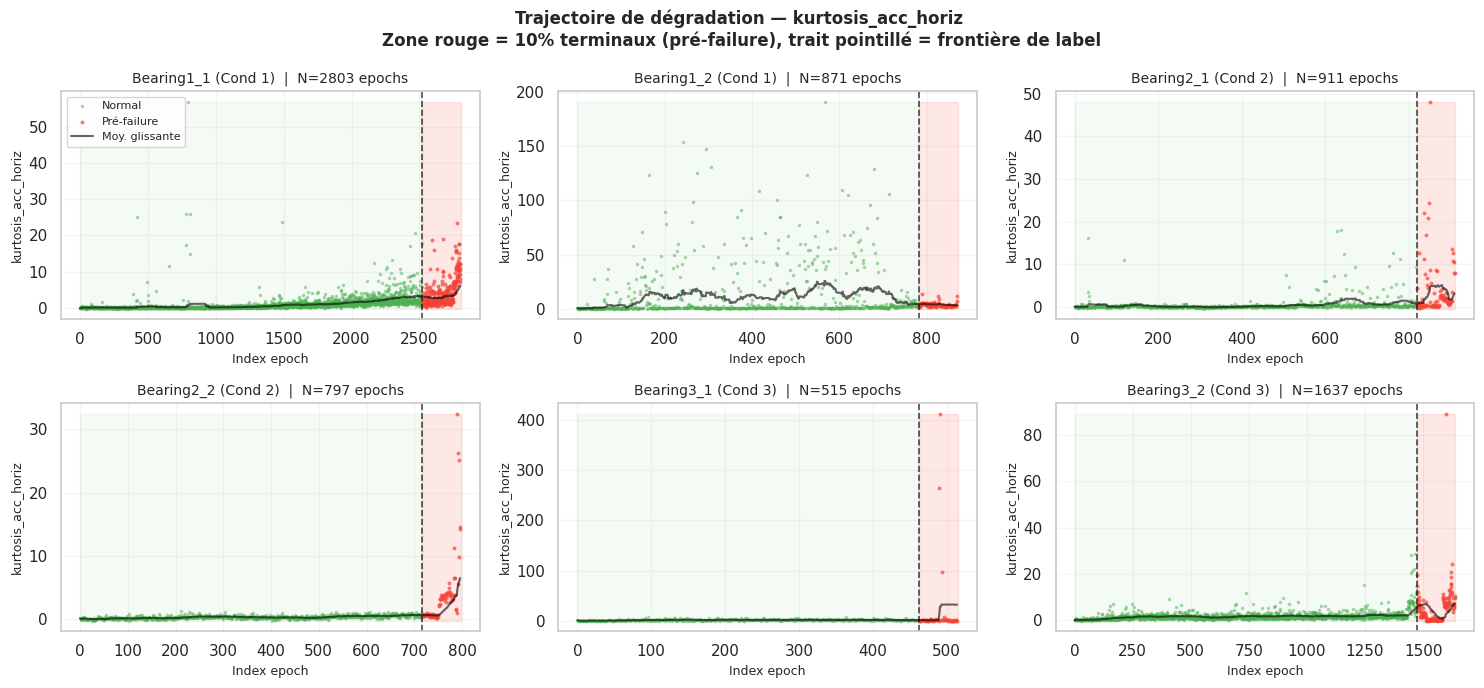

✓ Sauvegardé : figures/eda/pronostia/degradation_kurtosis_horiz.png


In [8]:
fig = plot_degradation_trajectory(
    "kurtosis_acc_horiz",
    save_path=FIGURES_DIR / "degradation_kurtosis_horiz.png"
)
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'degradation_kurtosis_horiz.png'}")

---
## Section 4 — Distribution des features (normal vs pré-failure)

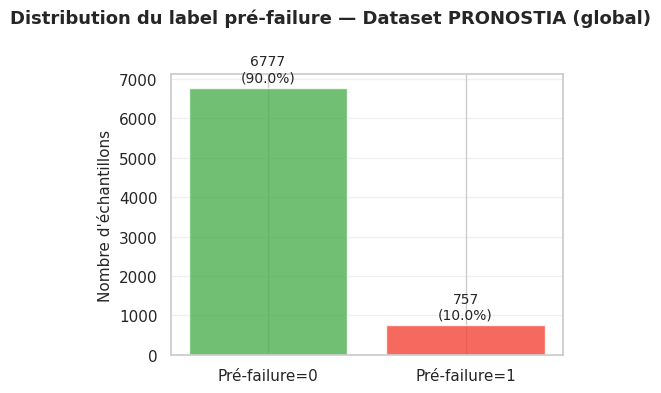

✓ figures/eda/pronostia/label_distribution_global.png


In [9]:
# Distribution globale du label
fig = plot_label_distribution(
    df_all, label_col="label", label_name="Pré-failure",
    title="Distribution du label pré-failure — Dataset PRONOSTIA (global)"
)
fig.savefig(FIGURES_DIR / "label_distribution_global.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'label_distribution_global.png'}")

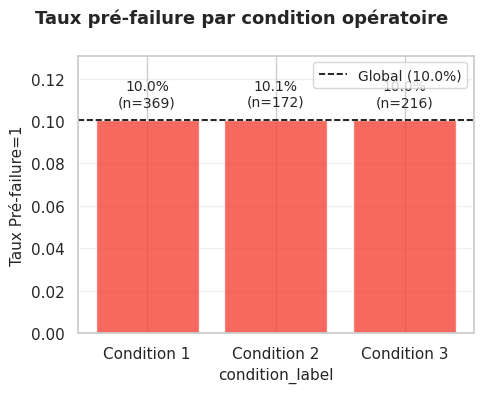

✓ figures/eda/pronostia/label_distribution_by_condition.png


In [10]:
# Taux pré-failure par condition
fig = plot_label_distribution(
    df_all, label_col="label", label_name="Pré-failure",
    group_col="condition_label",
    title="Taux pré-failure par condition opératoire"
)
fig.savefig(FIGURES_DIR / "label_distribution_by_condition.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'label_distribution_by_condition.png'}")

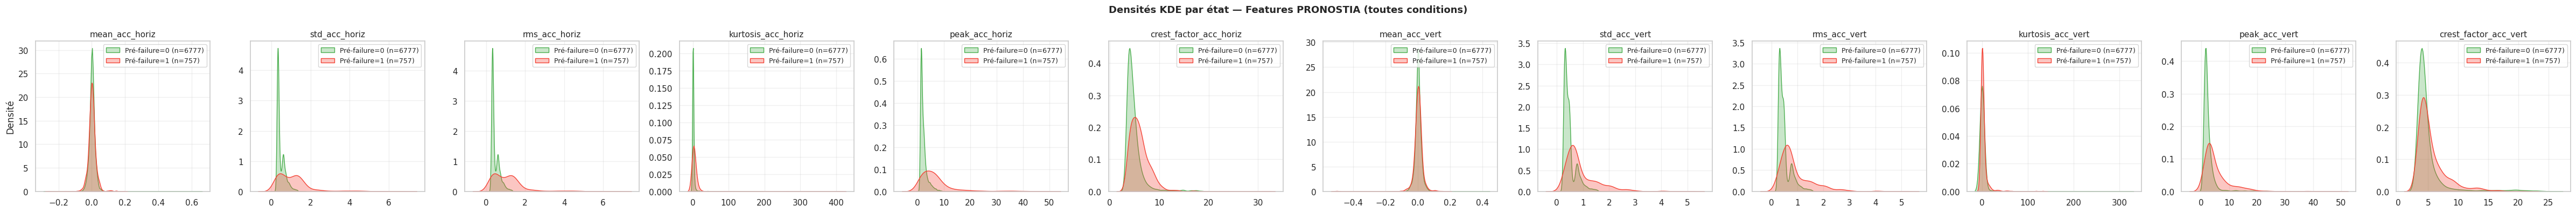

✓ figures/eda/pronostia/kde_features_by_label.png


In [11]:
# KDE des 12 features acc
fig = plot_kde_by_label(
    df_all,
    feature_cols=ACC_FEATURES,
    label_col="label",
    label_name="Pré-failure",
    title="Densités KDE par état — Features PRONOSTIA (toutes conditions)",
)
fig.savefig(FIGURES_DIR / "kde_features_by_label.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'kde_features_by_label.png'}")

/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed num

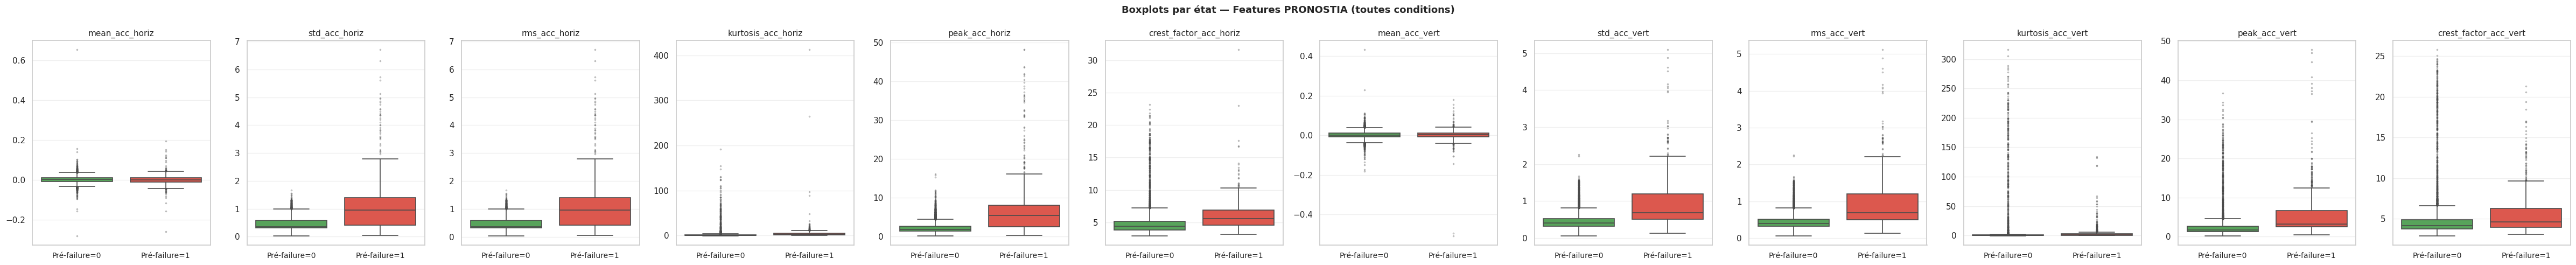

✓ figures/eda/pronostia/boxplots_features_by_label.png


In [12]:
# Boxplots des 12 features acc
fig = plot_boxplots_by_label(
    df_all,
    feature_cols=ACC_FEATURES,
    label_col="label",
    label_name="Pré-failure",
    title="Boxplots par état — Features PRONOSTIA (toutes conditions)",
)
fig.savefig(FIGURES_DIR / "boxplots_features_by_label.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'boxplots_features_by_label.png'}")

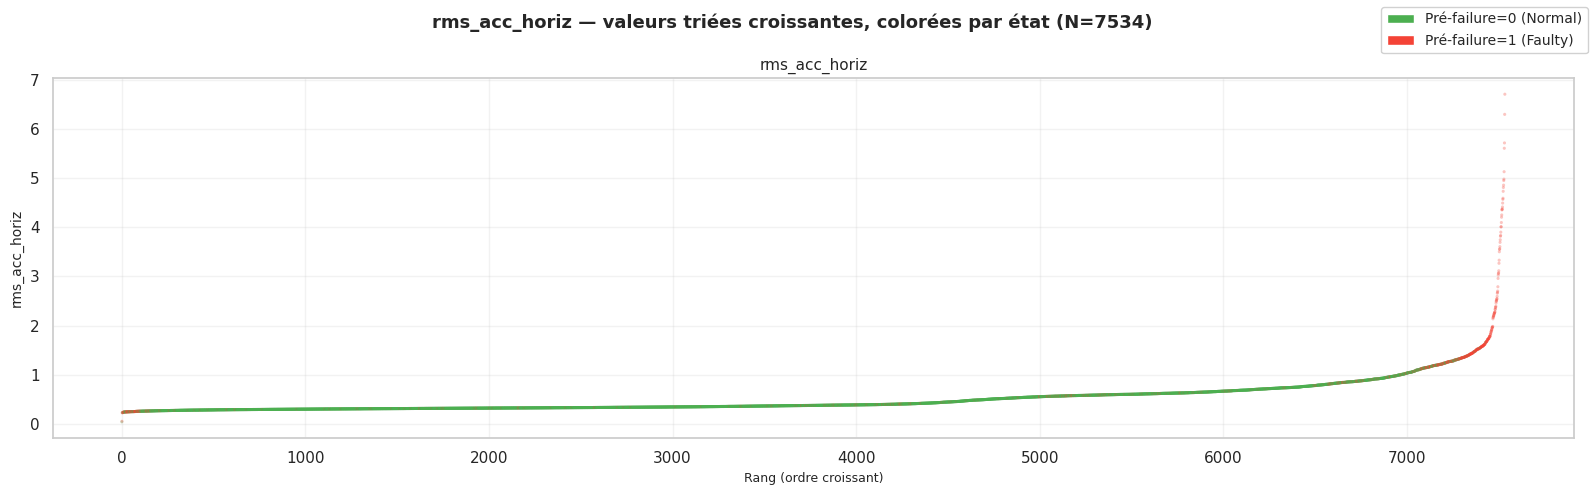

✓ figures/eda/pronostia/sorted_scatter_rms_acc_horiz.png


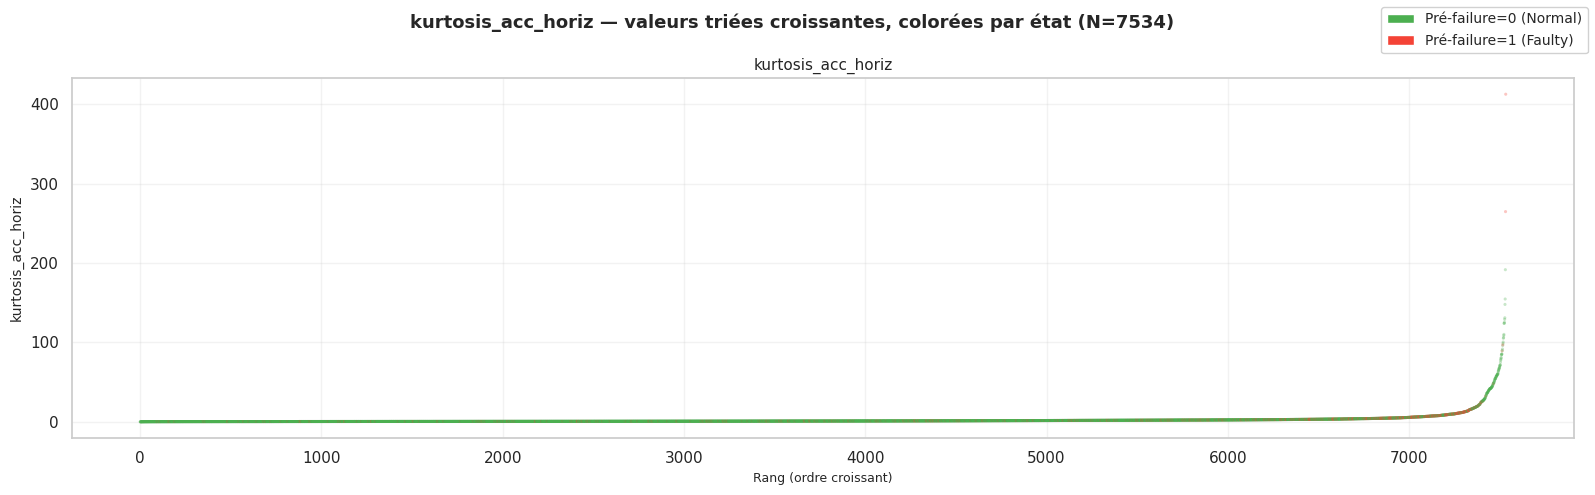

✓ figures/eda/pronostia/sorted_scatter_kurtosis_acc_horiz.png


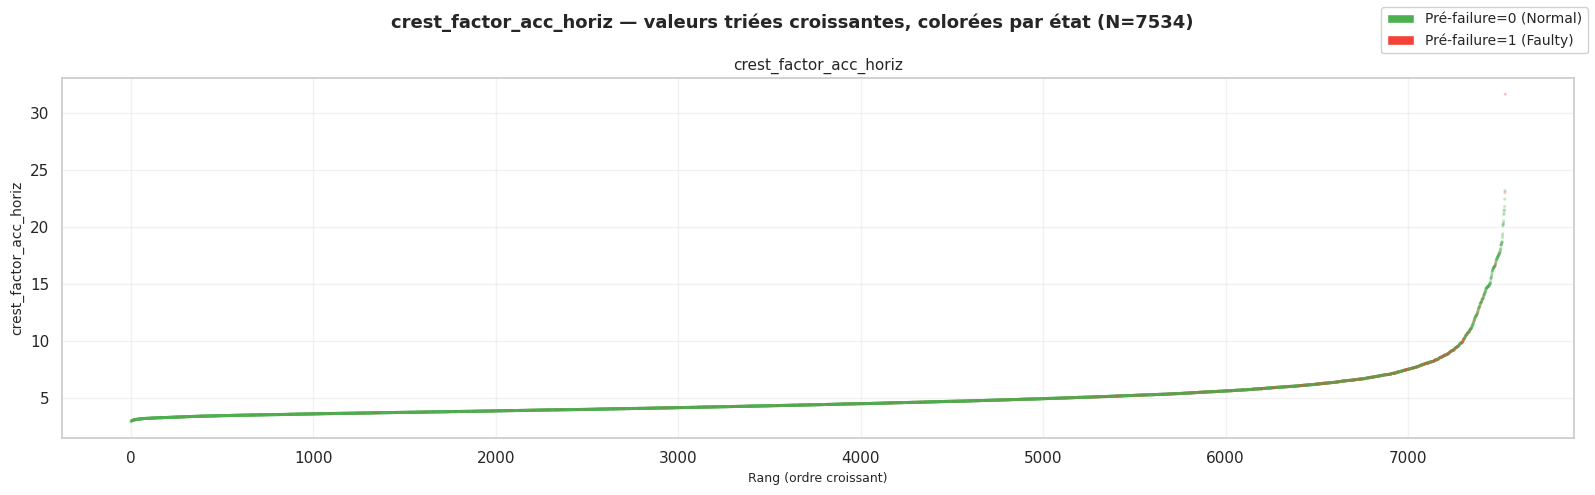

✓ figures/eda/pronostia/sorted_scatter_crest_factor_acc_horiz.png


In [13]:
# Sorted scatter sur les 3 features les plus discriminantes
key_features = ["rms_acc_horiz", "kurtosis_acc_horiz", "crest_factor_acc_horiz"]
for feat in key_features:
    fig = plot_sorted_scatter_by_label(
        df_all,
        feature_cols=[feat],
        label_col="label",
        label_name="Pré-failure",
        alpha=0.3,
        s=5,
        title=f"{feat} — valeurs triées croissantes, colorées par état (N={len(df_all)})",
        save_path=FIGURES_DIR / f"sorted_scatter_{feat}.png",
    )
    plt.show()
    print(f"✓ {FIGURES_DIR / f'sorted_scatter_{feat}.png'}")

In [14]:
# Séparation quantitative : delta de moyenne entre normal et pré-failure
stats_normal = df_all[df_all["label"] == 0][ACC_FEATURES].agg(["mean", "std"])
stats_fail   = df_all[df_all["label"] == 1][ACC_FEATURES].agg(["mean", "std"])

sep = pd.DataFrame({
    "mean_normal": stats_normal.loc["mean"],
    "mean_failure": stats_fail.loc["mean"],
    "std_normal": stats_normal.loc["std"],
    "std_failure": stats_fail.loc["std"],
})
sep["delta_mean_pct"] = ((sep["mean_failure"] - sep["mean_normal"]).abs() / (sep["mean_normal"].abs() + 1e-9)) * 100
sep["std_ratio"] = sep["std_failure"] / (sep["std_normal"] + 1e-9)

print("Séparation normal vs pré-failure par feature (triée par delta_mean_pct) :")
display(sep[["mean_normal", "mean_failure", "delta_mean_pct", "std_ratio"]]
        .sort_values("delta_mean_pct", ascending=False).round(3))

Séparation normal vs pré-failure par feature (triée par delta_mean_pct) :


,mean_normal,mean_failure,delta_mean_pct,std_ratio
peak_acc_horiz,2.262,7.171,216.949997,5.361
std_acc_horiz,0.463,1.112,140.412003,4.388
rms_acc_horiz,0.463,1.113,140.287003,4.390
kurtosis_acc_horiz,2.222,5.041,126.860001,2.109
peak_acc_vert,2.606,5.569,113.695000,1.866
std_acc_vert,0.482,0.936,94.366997,2.825
rms_acc_vert,0.482,0.937,94.330002,2.825
kurtosis_acc_vert,5.788,3.829,33.855000,0.411
crest_factor_acc_horiz,4.910,6.054,23.296000,1.071
mean_acc_horiz,0.001,0.001,23.233999,1.387


---
## Section 5 — Shift de domaine entre conditions CL

Pour valider le scénario Domain-Incremental : les distributions de features **normales** doivent différer significativement entre les 3 conditions (sinon un modèle unique suffirait, ce qui rendrait le CL non nécessaire).

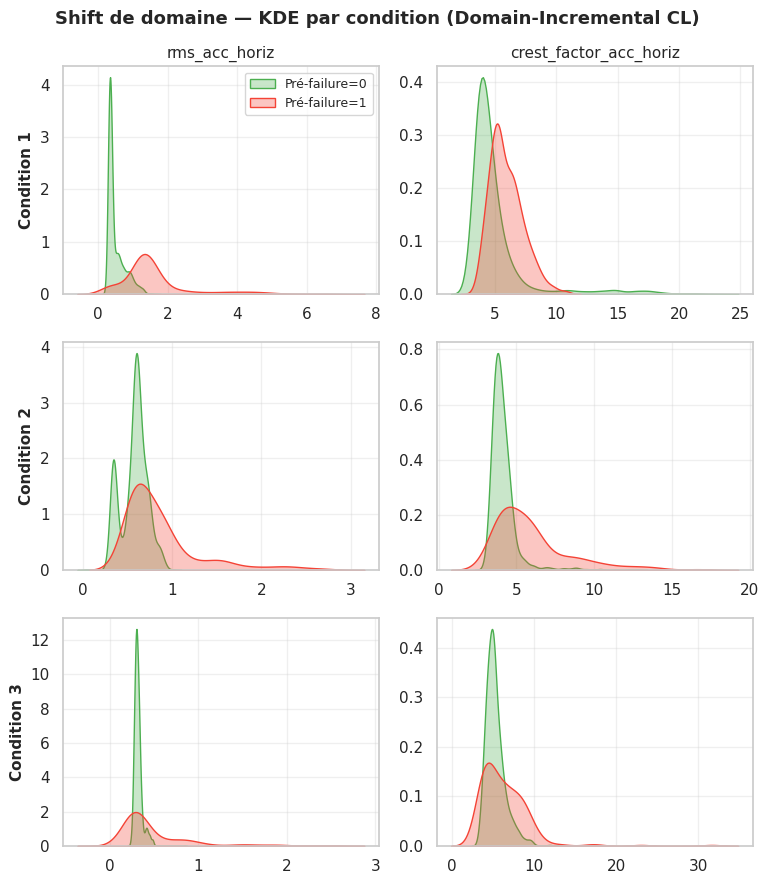

✓ figures/eda/pronostia/kde_domain_shift_by_condition.png


In [15]:
# KDE par condition et par label — 2 features clés
domain_features = ["rms_acc_horiz", "crest_factor_acc_horiz"]
fig = plot_kde_by_group_and_label(
    df_all,
    feature_cols=domain_features,
    label_col="label",
    group_col="condition_label",
    label_name="Pré-failure",
    title="Shift de domaine — KDE par condition (Domain-Incremental CL)",
)
fig.savefig(FIGURES_DIR / "kde_domain_shift_by_condition.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'kde_domain_shift_by_condition.png'}")

/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:549: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:558: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:549: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:558: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

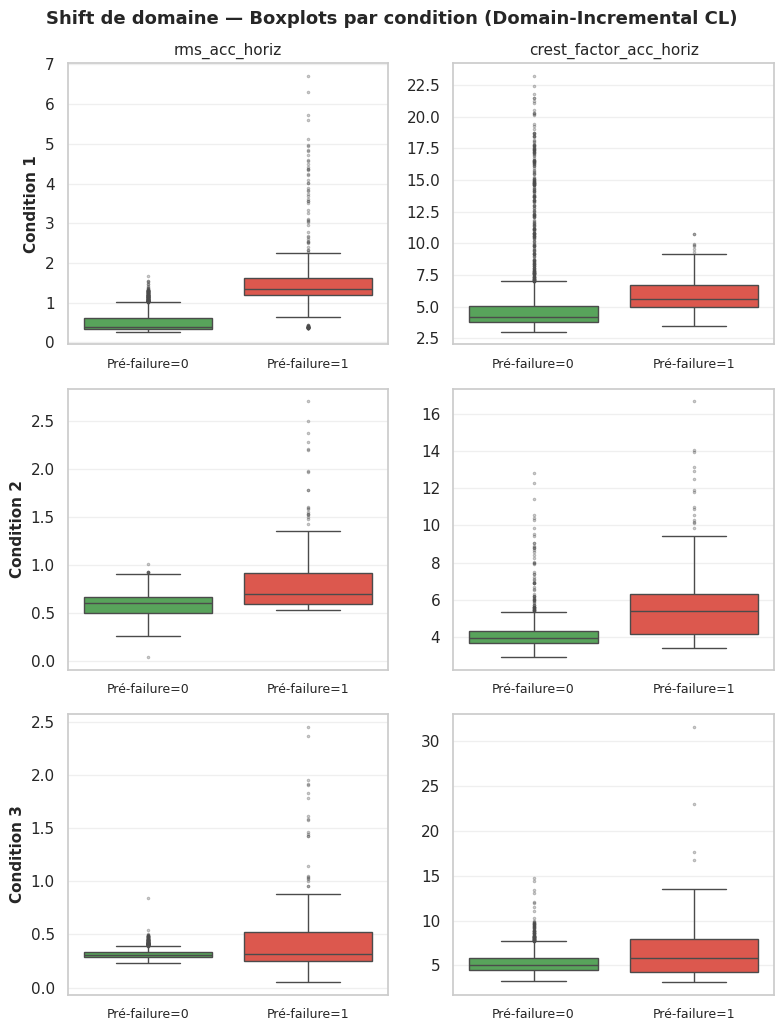

✓ figures/eda/pronostia/boxplots_domain_shift_by_condition.png


In [16]:
# Boxplots par condition et label
fig = plot_boxplots_by_group_and_label(
    df_all,
    feature_cols=domain_features,
    label_col="label",
    group_col="condition_label",
    label_name="Pré-failure",
    title="Shift de domaine — Boxplots par condition (Domain-Incremental CL)",
)
fig.savefig(FIGURES_DIR / "boxplots_domain_shift_by_condition.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'boxplots_domain_shift_by_condition.png'}")

In [17]:
# Quantification du shift : RMS moyen par condition (états normaux seulement)
shift_table = (
    df_all[df_all["label"] == 0]
    .groupby("condition_label")[["rms_acc_horiz", "rms_acc_vert",
                                  "crest_factor_acc_horiz", "kurtosis_acc_horiz"]]
    .agg(["mean", "std"])
    .round(4)
)
print("RMS et crest_factor NORMAUX par condition (justification du Domain-Incremental) :")
display(shift_table)

RMS et crest_factor NORMAUX par condition (justification du Domain-Incremental) :


rms_acc_horiz         rms_acc_vert          \
                         mean     std         mean     std   
condition_label                                              
Condition 1            0.4991  0.2451       0.4604  0.1460   
Condition 2            0.5725  0.1448       0.7622  0.3042   
Condition 3            0.3151  0.0451       0.2970  0.0391   

                crest_factor_acc_horiz         kurtosis_acc_horiz           
                                  mean     std               mean      std  
condition_label                                                             
Condition 1                     5.0582  2.7100             3.3130  12.5285  
Condition 2                     4.1185  0.8915             0.4321   1.2065  
Condition 3                     5.2854  1.2455             1.7798   1.8832

---
## Section 6 — Corrélation entre features

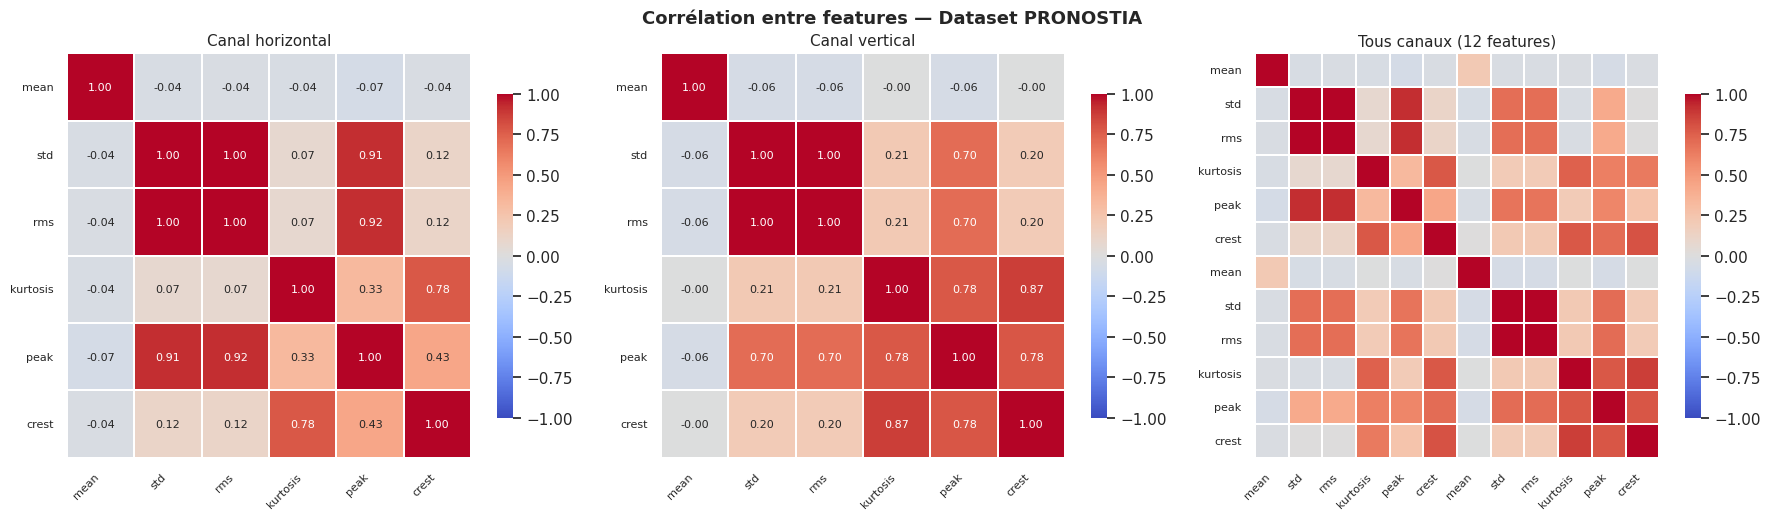

✓ figures/eda/pronostia/correlation_matrix.png


In [18]:
horiz_features = [f for f in ACC_FEATURES if "horiz" in f]
vert_features  = [f for f in ACC_FEATURES if "vert" in f]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feats, title in [
    (axes[0], horiz_features, "Canal horizontal"),
    (axes[1], vert_features,  "Canal vertical"),
    (axes[2], ACC_FEATURES,   "Tous canaux (12 features)"),
]:
    corr = df_all[feats].corr()
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True if len(feats) > 6 else False
    sns.heatmap(
        corr, ax=ax,
        annot=len(feats) <= 6, fmt=".2f", annot_kws={"size": 8},
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.3, cbar_kws={"shrink": 0.8},
    )
    short_labels = [f.split("_")[0] for f in feats]
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short_labels, rotation=0, fontsize=8)
    ax.set_title(title, fontsize=FIGURE_FONT_SIZE)

fig.suptitle("Corrélation entre features — Dataset PRONOSTIA",
             fontsize=FIGURE_FONT_SIZE + 2, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'correlation_matrix.png'}")

---
## Section 7 — PCA de l'espace des features

Projection 2D après normalisation Z-score (nécessaire car les features ont des échelles très différentes).
Deux vues : colorée par **label** (normal/failure) et par **condition** (tâches CL).

Variance expliquée : PC1=42.5%, PC2=24.2%, Total=66.8%


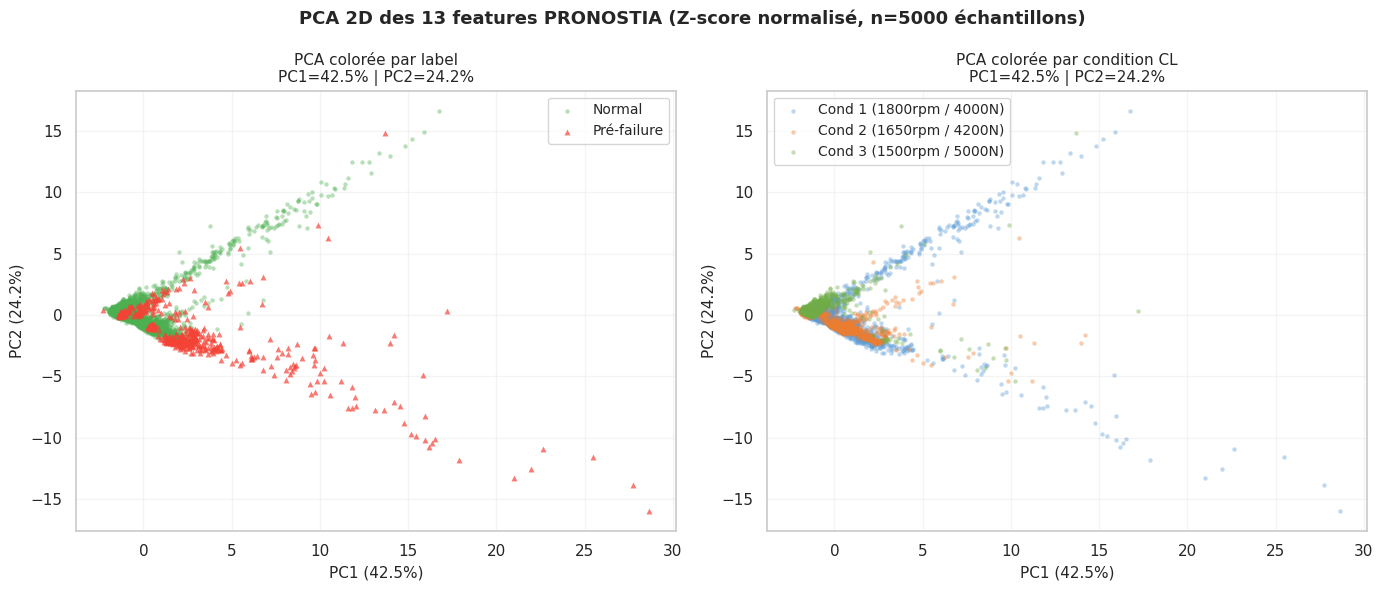

✓ figures/eda/pronostia/pca_features.png


In [19]:
X = df_all[FEATURE_NAMES].values
y_label = df_all["label"].values
y_cond  = df_all["condition"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f"Variance expliquée : PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}, "
      f"Total={var_explained.sum():.1%}")

# Sous-échantillonnage pour la visualisation (évite surcharge)
rng = np.random.default_rng(42)
n_plot = min(5000, len(X_pca))
idx_sample = rng.choice(len(X_pca), n_plot, replace=False)
X_plot = X_pca[idx_sample]
y_label_plot = y_label[idx_sample]
y_cond_plot  = y_cond[idx_sample]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vue 1 : coloré par label
for v, name, marker in [(0, "Normal", "o"), (1, "Pré-failure", "^")]:
    mask = y_label_plot == v
    axes[0].scatter(
        X_plot[mask, 0], X_plot[mask, 1],
        c=COLORS_LABEL[v], alpha=0.4 if v == 0 else 0.7,
        s=10 if v == 0 else 18, marker=marker, linewidths=0,
        label=name, zorder=2 if v == 1 else 1
    )
axes[0].set_title(
    f"PCA colorée par label\nPC1={var_explained[0]:.1%} | PC2={var_explained[1]:.1%}",
    fontsize=FIGURE_FONT_SIZE
)
axes[0].set_xlabel(f"PC1 ({var_explained[0]:.1%})", fontsize=FIGURE_FONT_SIZE)
axes[0].set_ylabel(f"PC2 ({var_explained[1]:.1%})", fontsize=FIGURE_FONT_SIZE)
axes[0].legend(fontsize=FIGURE_FONT_SIZE - 1)
axes[0].grid(True, alpha=0.2)

# Vue 2 : coloré par condition
cond_colors_pca = {1: "#5B9BD5", 2: "#ED7D31", 3: "#70AD47"}
for cond in [1, 2, 3]:
    mask = y_cond_plot == cond
    meta = CONDITION_META[cond]
    axes[1].scatter(
        X_plot[mask, 0], X_plot[mask, 1],
        c=cond_colors_pca[cond], alpha=0.4, s=10, linewidths=0,
        label=f"Cond {cond} ({meta['rpm']}rpm / {meta['load_N']}N)"
    )
axes[1].set_title(
    f"PCA colorée par condition CL\nPC1={var_explained[0]:.1%} | PC2={var_explained[1]:.1%}",
    fontsize=FIGURE_FONT_SIZE
)
axes[1].set_xlabel(f"PC1 ({var_explained[0]:.1%})", fontsize=FIGURE_FONT_SIZE)
axes[1].set_ylabel(f"PC2 ({var_explained[1]:.1%})", fontsize=FIGURE_FONT_SIZE)
axes[1].legend(fontsize=FIGURE_FONT_SIZE - 1)
axes[1].grid(True, alpha=0.2)

fig.suptitle(
    f"PCA 2D des 13 features PRONOSTIA (Z-score normalisé, n={n_plot} échantillons)",
    fontsize=FIGURE_FONT_SIZE + 2, fontweight="bold"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pca_features.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ {FIGURES_DIR / 'pca_features.png'}")

---
## Observations

### Section 1 — Vue d'ensemble
- Les durées de vie varient fortement selon les roulements et les conditions — le nombre d'epochs est hétérogène, ce qui rend le scénario de classe imbalancée inévitable (label fixing à 10% terminal).

### Section 2 — Signal brut
- L'amplitude du signal d'accélération augmente nettement en pré-défaillance : l'élévation du RMS est visible à l'œil nu. Le canal horizontal et vertical évoluent de façon cohérente.

### Section 3 — Trajectoire de dégradation
- Le RMS reste stable pendant une longue phase nominale puis s'emballe brusquement dans la zone terminale — classique des dégradations de roulements (spalling). Le crest_factor est plus bruité mais détecte les chocs impulsifs précoces.

### Section 4 — Features normales vs pré-failure
- Le RMS, le peak et le crest_factor montrent la meilleure séparation. Le mean est peu discriminant (signal centré sur 0). Le kurtosis est sensible mais bruité.

### Section 5 — Shift inter-conditions
- Les distributions normales diffèrent significativement entre les 3 conditions (niveaux de RMS, d'amplitude). Cela **valide** le scénario Domain-Incremental : un modèle entraîné sur Condition 1 sera en distribution shift sur Condition 2 et 3 — justification directe du besoin de CL.

### Section 6 — Corrélations
- Le RMS, std et peak sont fortement corrélés entre eux (redondance au sein d'un canal). Le kurtosis et le crest_factor apportent une information complémentaire. La corrélation horiz/vert est modérée.

### Section 7 — PCA
- Les points pré-failure se séparent partiellement sur PC1 (axe dominant). Les clusters par condition sont distincts, confirmant le shift de domaine. **Implication Gap 1** : la structure exploitable du dataset justifie le positionnement comme première validation CL sur des données industrielles réelles de roulements.